# Initial EDA: Crypto Meme Coin Dashboard

This notebook extends the initial exploration with volatility analysis, coin comparison, and Power BI-ready insights. The goal is to support dashboard storytelling for meme coins and benchmark coins together.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
from pathlib import Path

plt.style.use('seaborn-v0_8')
DATA_PATH = Path('../data/interim/master_cleaned.csv')
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df.head()

,date,coin_id,price,volume,market_cap,daily_return_pct,price_7d_ma,volume_7d_ma
0,2025-04-08,bitcoin,79179.292268,8.290975e+10,1.581408e+12,NaN,NaN,NaN
1,2025-04-09,bitcoin,76329.090356,4.781279e+10,1.515042e+12,-3.599681,NaN,NaN
2,2025-04-10,bitcoin,82622.170295,8.740822e+10,1.640568e+12,8.244668,NaN,NaN
3,2025-04-11,bitcoin,79596.357323,4.121352e+10,1.580023e+12,-3.662229,NaN,NaN
4,2025-04-12,bitcoin,83439.288180,3.981357e+10,1.655869e+12,4.828024,NaN,NaN


In [12]:
df.shape

(1464, 8)

In [13]:
df["coin_id"].value_counts()

coin_id
bitcoin           366
dogwifcoin        366
floki             366
official-trump    366
Name: count, dtype: int64

In [14]:
df["date"].min(), df["date"].max()

(Timestamp('2025-04-08 00:00:00'), Timestamp('2026-04-07 00:00:00'))

In [15]:
print('Rows:', len(df))
print('Columns:', df.shape[1])
print('Coins:', df['coin_id'].nunique())
print('Date range:', df['date'].min(), '->', df['date'].max())
print('Missing values by column:')
print(df.isnull().sum())


Rows: 1464
Columns: 8
Coins: 4
Date range: 2025-04-08 00:00:00 -> 2026-04-07 00:00:00
Missing values by column:
date                 0
coin_id              0
price                0
volume               0
market_cap           0
daily_return_pct     4
price_7d_ma         24
volume_7d_ma        24
dtype: int64


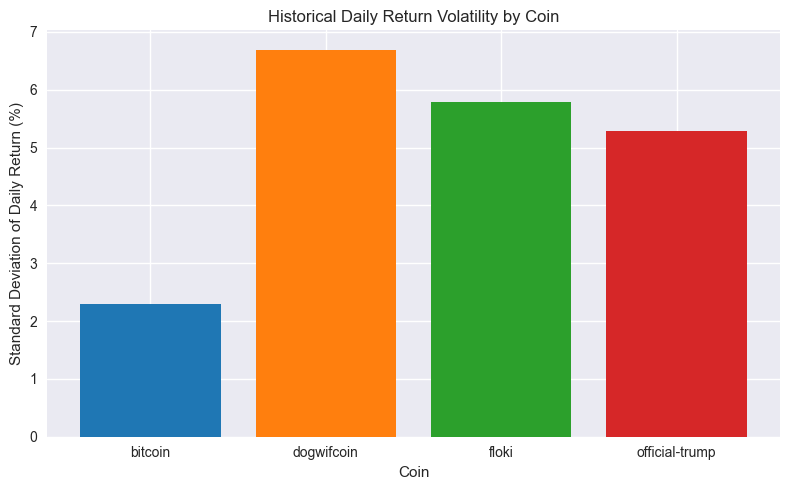

,coin_id,return_volatility
0,bitcoin,2.29
1,dogwifcoin,6.69
2,floki,5.78
3,official-trump,5.28


In [16]:
volatility = df.groupby('coin_id')['daily_return_pct'].std().reset_index()
volatility.columns = ['coin_id', 'return_volatility']
volatility['return_volatility'] = volatility['return_volatility'].round(2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(volatility['coin_id'], volatility['return_volatility'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_title('Historical Daily Return Volatility by Coin')
ax.set_xlabel('Coin')
ax.set_ylabel('Standard Deviation of Daily Return (%)')
plt.tight_layout()
plt.show()
volatility

In [17]:
summary = df.groupby('coin_id').agg(
    avg_price=('price', 'mean'),
    avg_volume=('volume', 'mean'),
    avg_market_cap=('market_cap', 'mean'),
    avg_daily_return=('daily_return_pct', 'mean'),
    volatility_30d=('daily_return_pct', lambda x: x.rolling(30).std().mean()),
).reset_index()
summary['avg_price'] = summary['avg_price'].round(2)
summary['avg_volume'] = summary['avg_volume'].round(0)
summary['avg_market_cap'] = summary['avg_market_cap'].round(0)
summary['avg_daily_return'] = summary['avg_daily_return'].round(2)
summary['volatility_30d'] = summary['volatility_30d'].round(2)
summary

,coin_id,avg_price,avg_volume,avg_market_cap,avg_daily_return,volatility_30d
0,bitcoin,97145.45,4.610623e+10,1.935815e+12,-0.01,2.12
1,dogwifcoin,0.59,2.583377e+08,5.882104e+08,0.04,6.55
2,floki,0.00,1.032185e+08,6.632781e+08,-0.01,5.67
3,official-trump,7.42,4.695064e+08,1.503159e+09,-0.15,4.52


In [18]:
query = '''
SELECT
    coin_id,
    COUNT(*) AS observations,
    MIN(date) AS first_date,
    MAX(date) AS last_date,
    AVG(price) AS avg_price,
    AVG(volume) AS avg_volume,
    AVG(market_cap) AS avg_market_cap
FROM df
GROUP BY coin_id
ORDER BY avg_market_cap DESC
'''
coin_compare = duckdb.query(query).to_df()
coin_compare['avg_price'] = coin_compare['avg_price'].round(2)
coin_compare['avg_volume'] = coin_compare['avg_volume'].round(0)
coin_compare['avg_market_cap'] = coin_compare['avg_market_cap'].round(0)
coin_compare

,coin_id,observations,first_date,last_date,avg_price,avg_volume,avg_market_cap
0,bitcoin,366,2025-04-08,2026-04-07,97145.45,4.610623e+10,1.935815e+12
1,official-trump,366,2025-04-08,2026-04-07,7.42,4.695064e+08,1.503159e+09
2,floki,366,2025-04-08,2026-04-07,0.00,1.032185e+08,6.632781e+08
3,dogwifcoin,366,2025-04-08,2026-04-07,0.59,2.583377e+08,5.882104e+08
